In [1]:
import pandas as pd
import numpy as np

# ── Load the key tables ──────────────────────────────────────────────
orders     = pd.read_csv('olist_orders_dataset.csv')
items      = pd.read_csv('olist_order_items_dataset.csv')
customers  = pd.read_csv('olist_customers_dataset.csv')
payments   = pd.read_csv('olist_order_payments_dataset.csv')
products   = pd.read_csv('olist_products_dataset.csv')

# ── Step 1: Inspect the data ─────────────────────────────────────────
print(orders.shape)           # (99441, 8)
print(orders.info())
print(orders.isnull().sum())  # Count missing values per column

# ── Step 2: Handle missing values ────────────────────────────────────
# Drop rows where the critical columns are null
orders.dropna(subset=['order_purchase_timestamp', 'customer_id'], inplace=True)

# Fill optional missing columns with sensible defaults
orders['order_approved_at'].fillna(orders['order_purchase_timestamp'], inplace=True)
products['product_category_name'].fillna('unknown', inplace=True)

# ── Step 3: Remove duplicates ─────────────────────────────────────────
print("Duplicates before:", orders.duplicated().sum())
orders.drop_duplicates(inplace=True)
print("Duplicates after:", orders.duplicated().sum())

# ── Step 4: Fix data types ────────────────────────────────────────────
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ── Step 5: Extract useful time features ─────────────────────────────
orders['order_year']    = orders['order_purchase_timestamp'].dt.year
orders['order_month']   = orders['order_purchase_timestamp'].dt.month
orders['order_quarter'] = orders['order_purchase_timestamp'].dt.quarter
orders['order_day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

# ── Step 6: Merge tables into one master dataset ──────────────────────
df = orders.merge(items,     on='order_id',    how='left')
df = df.merge(payments,      on='order_id',    how='left')
df = df.merge(customers,     on='customer_id', how='left')
df = df.merge(products,      on='product_id',  how='left')

# ── Step 7: Create derived columns ───────────────────────────────────
df['total_revenue'] = df['price'] + df['freight_value']
df['profit_margin'] = (df['price'] * 0.30).round(2)  # Assume 30% margin

# ── Step 8: Filter only delivered orders ─────────────────────────────
df_clean = df[df['order_status'] == 'delivered'].copy()

# ── Step 9: Remove outliers in price ─────────────────────────────────
q_low  = df_clean['price'].quantile(0.01)
q_high = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] >= q_low) & (df_clean['price'] <= q_high)]

# ── Step 10: Save clean data ─────────────────────────────────────────
df_clean.to_csv('retailpulse_clean.csv', index=False)
print("Clean data saved! Shape:", df_clean.shape)
print(df_clean.head(3))

(99441, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_cu

/tmp/ipykernel_727/1187625948.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['order_approved_at'].fillna(orders['order_purchase_timestamp'], inplace=True)
/tmp/ipykernel_727/1187625948.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

Duplicates before: 0
Duplicates after: 0
Clean data saved! Shape: (112798, 36)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10-10 21:25:13   
2          2017-10-04 19:55:00           2017-10-10 21:25:13   

  order_estimated_delivery_date  order_year  order_month  ...  \
0                    2017-10-18        2017          

In [3]:
import os
print(os.listdir('/content'))

['.config', 'olist_order_payments_dataset.csv', 'product_category_name_translation.csv', 'olist_order_reviews_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_orders_dataset.csv', 'olist_customers_dataset.csv', 'olist_products_dataset.csv', 'retailpulse_clean.csv', 'olist_geolocation_dataset.csv', 'sample_data']


In [4]:
df_clean.to_csv('retailpulse_clean.csv', index=False)
print("Done! Shape:", df_clean.shape)

Done! Shape: (112798, 36)


**Add a new cell and paste the full analysis code**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df = pd.read_csv('retailpulse_clean.csv', parse_dates=['order_purchase_timestamp'])
print("Loaded!", df.shape)

Loaded! (112798, 36)


**Monthly sales trend**

In [9]:
# Monthly revenue trend
monthly = df.groupby(['order_year', 'order_month'])['total_revenue'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['order_year','order_month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['period'], monthly['total_revenue'],
         marker='o', color='#2E86AB', linewidth=2.5, markersize=5)
plt.fill_between(monthly['period'], monthly['total_revenue'], alpha=0.1, color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

ValueError: to assemble mappings requires at least that [year, month, day] be specified: [month,year] is missing

In [7]:
print(df.columns.tolist())
print(df.head(2))

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_year', 'order_month', 'order_quarter', 'order_day_of_week', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_revenue', 'profit_margin']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_

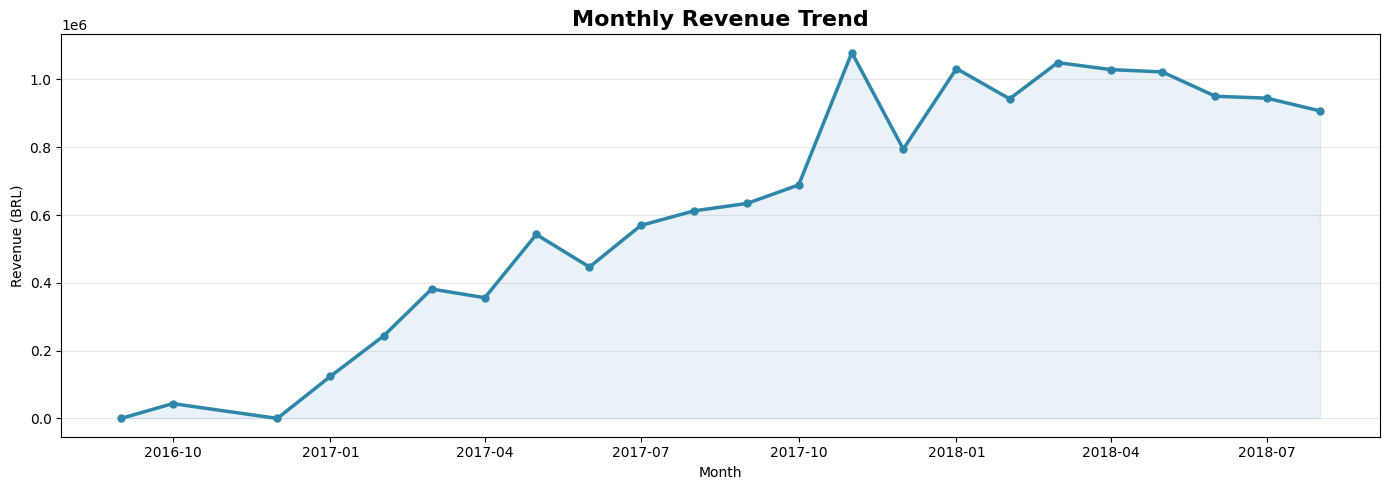

Chart saved!


In [8]:
# Fix: create year/month columns fresh from the timestamp
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_year']  = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month

# Monthly revenue trend
monthly = df.groupby(['order_year', 'order_month'])['total_revenue'].sum().reset_index()
monthly['period'] = pd.to_datetime({
    'year':  monthly['order_year'],
    'month': monthly['order_month'],
    'day':   1
})

plt.figure(figsize=(14, 5))
plt.plot(monthly['period'], monthly['total_revenue'],
         marker='o', color='#2E86AB', linewidth=2.5, markersize=5)
plt.fill_between(monthly['period'], monthly['total_revenue'], alpha=0.1, color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

**Cell — Top Categories**

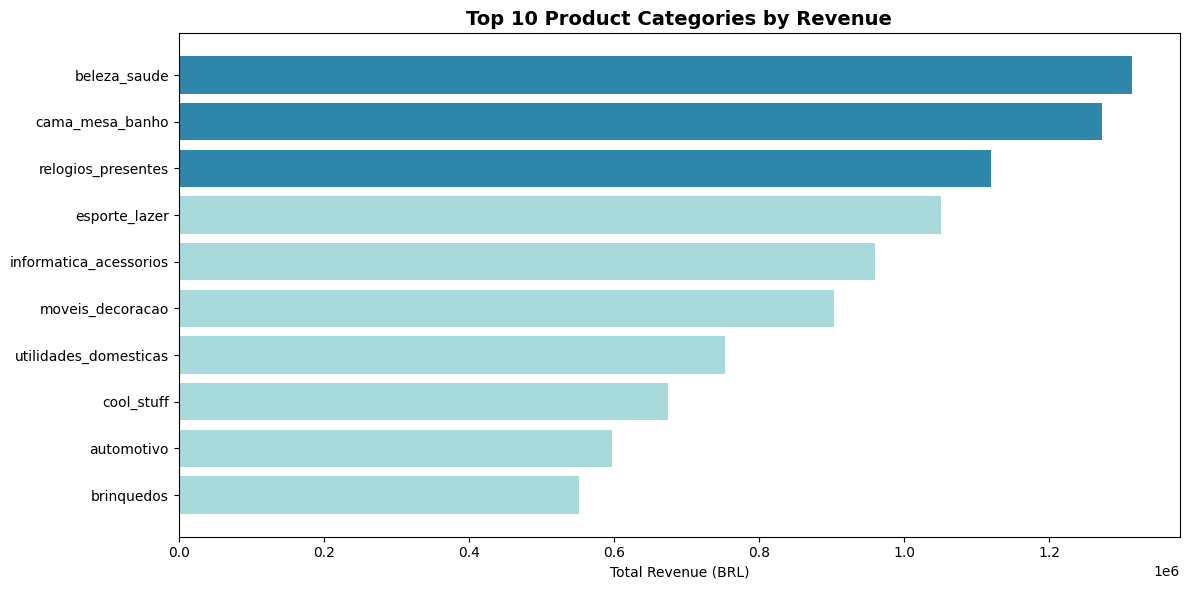

    product_category_name  total_revenue
0            beleza_saude     1314240.23
1         cama_mesa_banho     1272530.31
2      relogios_presentes     1119875.28
3           esporte_lazer     1051038.91
4  informatica_acessorios      959801.63
5        moveis_decoracao      903341.29
6   utilidades_domesticas      753010.62
7              cool_stuff      674180.26
8              automotivo      596394.78
9              brinquedos      551739.81


In [10]:
top_cats = (df.groupby('product_category_name')['total_revenue']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

plt.figure(figsize=(12, 6))
colors = ['#2E86AB' if i < 3 else '#A8DADC' for i in range(10)]
plt.barh(top_cats['product_category_name'], top_cats['total_revenue'], color=colors)
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()
print(top_cats)

**Cell — RFM Segmentation**

In [11]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('total_revenue', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_total'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_total'].apply(segment)
print(rfm['Segment'].value_counts())
rfm.to_csv('rfm_segments.csv', index=False)
print("Saved!")

Segment
Loyal Customers    47762
At Risk            23081
Champions          14932
Lost                5967
Name: count, dtype: int64
Saved!


**Cell — Region Performance**

In [12]:
region = (df.groupby('customer_state')
            .agg(
                total_revenue   = ('total_revenue', 'sum'),
                total_orders    = ('order_id', 'nunique'),
                avg_order_value = ('total_revenue', 'mean')
            )
            .sort_values('total_revenue', ascending=False)
            .reset_index())

print(region.head())
region.to_csv('region_performance.csv', index=False)
print("Saved!")

  customer_state  total_revenue  total_orders  avg_order_value
0             SP     5506702.01         39844       115.723485
1             RJ     1910150.56         12121       131.074628
2             MG     1685139.07         11162       127.933425
3             RS      810521.18          5260       129.290346
4             PR      725216.74          4816       126.388418
Saved!


**Download all files to your computer**

In [14]:
from google.colab import files

files.download('retailpulse_clean.csv')
files.download('rfm_segments.csv')
files.download('region_performance.csv')
print("All downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded!


Install Prophet

In [15]:
!pip install prophet

**Run the forecast**

In [16]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Load clean data
df = pd.read_csv('retailpulse_clean.csv',
                  parse_dates=['order_purchase_timestamp'])

# Prepare data for Prophet
daily_sales = (df.groupby(
    df['order_purchase_timestamp'].dt.date)['total_revenue']
    .sum()
    .reset_index())
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print("Data ready! Shape:", daily_sales.shape)
print(daily_sales.head())

Data ready! Shape: (612, 2)
          ds        y
0 2016-09-15   143.46
1 2016-10-03   559.53
2 2016-10-04  8523.00
3 2016-10-05  7423.12
4 2016-10-06  6798.90


**Train and forecast**

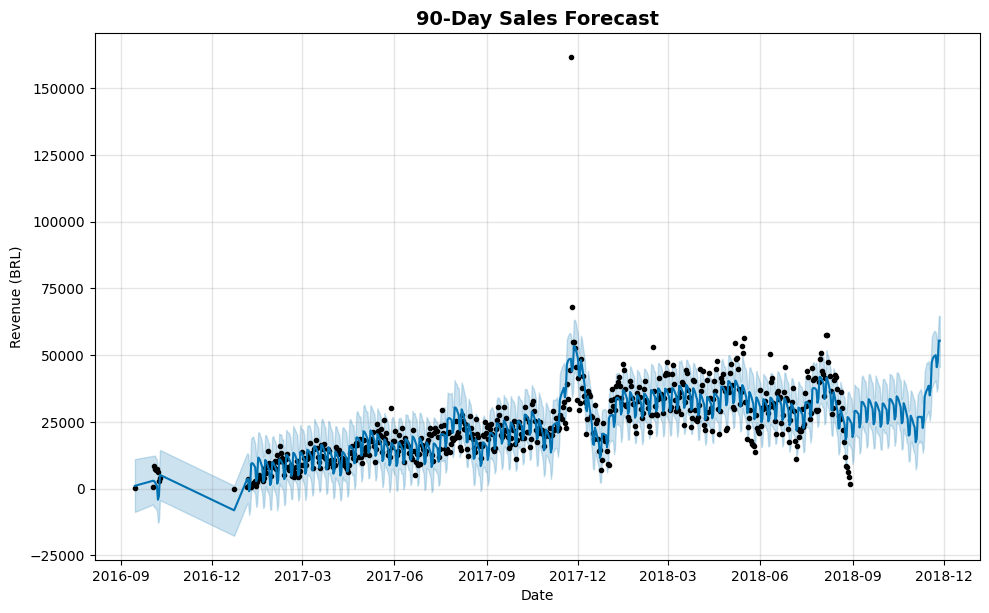

Forecast done!
            ds          yhat    yhat_lower    yhat_upper
692 2018-11-18  37805.220829  28301.630981  47736.350977
693 2018-11-19  47243.029429  37688.574787  56546.324331
694 2018-11-20  48607.236379  38407.952201  57846.297250
695 2018-11-21  49384.493014  39579.156876  58827.878528
696 2018-11-22  49683.314064  39984.806500  59109.313499
697 2018-11-23  49981.258155  40365.125021  58513.160655
698 2018-11-24  45459.718494  36295.620557  55811.146063
699 2018-11-25  47286.668323  37952.518959  56916.896627
700 2018-11-26  55464.538330  46181.855661  64753.799023
701 2018-11-27  55407.106566  45509.693279  64730.812716


In [17]:
# Train model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(daily_sales)

# Forecast 90 days ahead
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)
plt.title('90-Day Sales Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (BRL)')
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

print("Forecast done!")
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(10))

**Save forecast**

In [18]:
forecast.to_csv('sales_forecast.csv', index=False)

from google.colab import files
files.download('sales_forecast.csv')
files.download('sales_forecast.png')
print("Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
